In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelSpreading
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Usaremos o mesmo pipeline de pré-processamento e o LabelEncoder do passo anterior
# Recarregando os dados para garantir um ambiente limpo
data_path = '../../data/raw/UNSW-NB15'

df_train = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_training-set.csv'))
df_train = df_train.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')

X_train = df_train.drop(['attack_cat', 'label'], axis=1)
y_train_text = df_train['attack_cat']

# Identificando colunas numéricas e categóricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Inicializar o LabelEncoder
label_encoder = LabelEncoder()

# Aprender a correspondência entre texto e número usando APENAS os dados de treino
label_encoder.fit(y_train_text)

# Criando o pré-processador com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Mantém colunas não especificadas (se houver)
)

# Aplicando o pré-processamento (fit e transform)
# É importante que os dados estejam totalmente numéricos e na mesma escala
X_train_processed = preprocessor.fit_transform(X_train)
y_train_encoded = label_encoder.fit_transform(y_train_text)

print(f"Formato dos dados processados: {X_train_processed.shape}")

# --- SIMULAÇÃO DO CENÁRIO SEMI-SUPERVISIONADO ---

# Definir a porcentagem de dados que permanecerão rotulados
labeled_percentage = 0.1 # Usaremos apenas 10% dos rótulos

# Criar uma cópia dos rótulos para modificação
y_semi_supervised = np.copy(y_train_encoded)

# Sortear aleatoriamente os índices dos rótulos que vamos "esconder"
# O número de amostras a serem mantidas
n_labeled_points = int(len(y_train_encoded) * labeled_percentage)
# Gerar índices aleatórios para esconder os rótulos
unlabeled_indices = np.arange(len(y_train_encoded))
np.random.shuffle(unlabeled_indices)
unlabeled_indices = unlabeled_indices[n_labeled_points:]

# Esconder os rótulos. O valor -1 é o padrão para indicar amostras não rotuladas no scikit-learn
y_semi_supervised[unlabeled_indices] = -1

n_labeled = np.sum(y_semi_supervised != -1)
n_unlabeled = np.sum(y_semi_supervised == -1)

print(f"\nCenário semi-supervisionado criado:")
print(f"Amostras rotuladas: {n_labeled} ({labeled_percentage*100:.1f}%)")
print(f"Amostras não rotuladas (rótulos escondidos): {n_unlabeled} ({(1-labeled_percentage)*100:.1f}%)")

Formato dos dados processados: (175341, 194)

Cenário semi-supervisionado criado:
Amostras rotuladas: 17534 (10.0%)
Amostras não rotuladas (rótulos escondidos): 157807 (90.0%)


In [3]:
# Instanciando o modelo Label Spreading
label_spreading_model = LabelSpreading(kernel='knn', 
                                       n_neighbors=10,
                                       alpha=0.2,
                                       n_jobs=-1)

print("Iniciando o treinamento do modelo Label Spreading...")
print("Este processo pode ser demorado...")

start_time = time.time()
# Treinando o modelo com os dados processados e os rótulos parcialmente escondidos
label_spreading_model.fit(X_train_processed, y_semi_supervised)
end_time = time.time()

print(f"Treinamento concluído em {((end_time - start_time) / 60):.2f} minutos.")

Iniciando o treinamento do modelo Label Spreading...
Este processo pode ser demorado...
Treinamento concluído em 11.68 minutos.


--- Relatório de Classificação (Inferência nos Dados Não Rotulados) ---
                precision    recall  f1-score   support

      Analysis       0.03      0.38      0.05      1781
      Backdoor       0.04      0.02      0.03      1588
           DoS       0.29      0.20      0.24     11042
      Exploits       0.67      0.56      0.61     30096
       Fuzzers       0.52      0.50      0.51     16371
       Generic       0.99      0.68      0.81     36086
        Normal       0.88      0.86      0.87     50314
Reconnaissance       0.53      0.49      0.51      9398
     Shellcode       0.28      0.24      0.26      1016
         Worms       0.09      0.08      0.08       115

      accuracy                           0.64    157807
     macro avg       0.43      0.40      0.40    157807
  weighted avg       0.74      0.64      0.68    157807



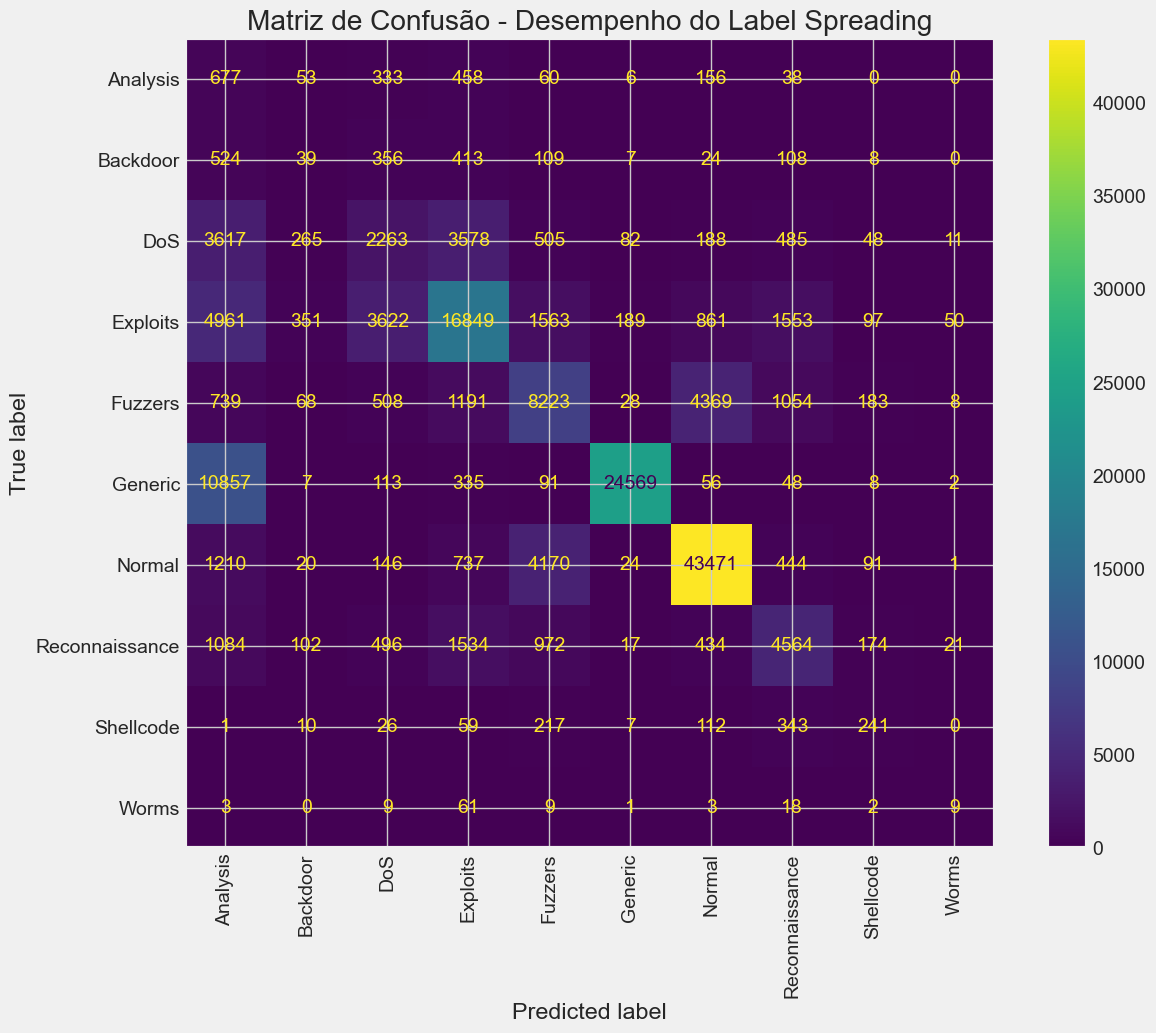

In [10]:
# O atributo `transduction_` contém os rótulos que o modelo inferiu para as amostras não rotuladas
predicted_labels_encoded = label_spreading_model.transduction_

# Pegar apenas os rótulos que foram originalmente escondidos para a avaliação
true_labels_unlabeled = y_train_encoded[unlabeled_indices]
predicted_labels_unlabeled = predicted_labels_encoded[unlabeled_indices]

# Decodificar os rótulos de volta para texto para facilitar a leitura do relatório
true_labels_text = label_encoder.inverse_transform(true_labels_unlabeled)
predicted_labels_text = label_encoder.inverse_transform(predicted_labels_unlabeled)

print("--- Relatório de Classificação (Inferência nos Dados Não Rotulados) ---")
print(classification_report(true_labels_text, predicted_labels_text))

# Gerando a Matriz de Confusão
class_names = label_encoder.classes_
cm = confusion_matrix(true_labels_text, predicted_labels_text, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='viridis', xticks_rotation='vertical')
plt.title('Matriz de Confusão - Desempenho do Label Spreading')
plt.savefig('confusion_matrix_atks_multi_ls.png')
plt.show()

--- Relatório de Classificação Binária (Inferência Semi-Supervisionada) ---
              precision    recall  f1-score   support

  Normal (0)       0.88      0.86      0.87     50314
  Ataque (1)       0.94      0.94      0.94    107493

    accuracy                           0.92    157807
   macro avg       0.91      0.90      0.90    157807
weighted avg       0.92      0.92      0.92    157807



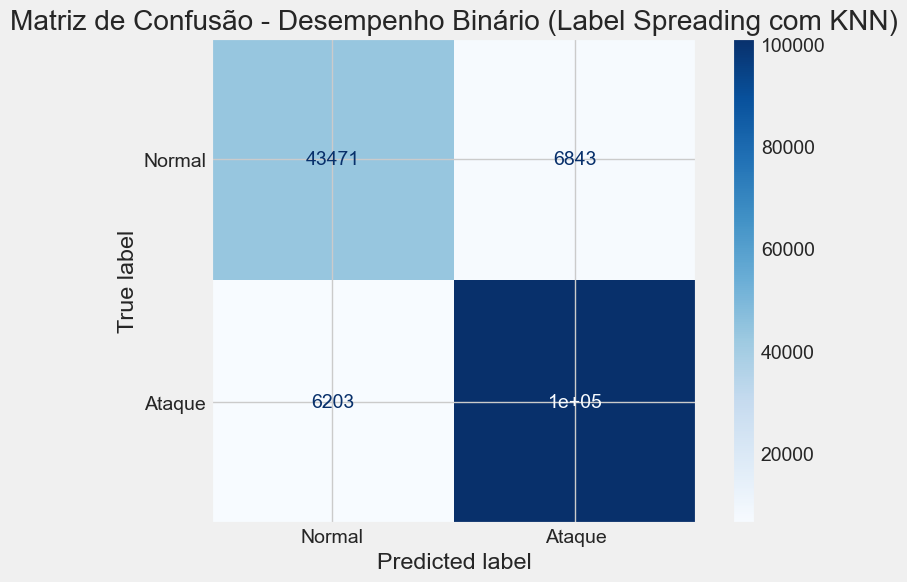

In [11]:
# --- Geração da Matriz de Confusão Binária (Label Spreading) ---

# Convertendo os rótulos de texto multiclasse para um formato binário
# 0 para 'Normal', 1 para qualquer tipo de ataque
true_labels_binary = np.where(true_labels_text == 'Normal', 0, 1)
predicted_labels_binary = np.where(predicted_labels_text == 'Normal', 0, 1)

print("--- Relatório de Classificação Binária (Inferência Semi-Supervisionada) ---")
print(classification_report(true_labels_binary, predicted_labels_binary, target_names=['Normal (0)', 'Ataque (1)']))

# Gerando e plotando a Matriz de Confusão Binária
cm_binary = confusion_matrix(true_labels_binary, predicted_labels_binary)
disp_binary = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=['Normal', 'Ataque'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_binary.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Desempenho Binário (Label Spreading com KNN)')
plt.savefig('confusion_matrix_multi_ls.png')
plt.show()

In [9]:
# Exportação dos artefatos

try:
    # Salvar o Pré-processador
    joblib.dump(preprocessor, 'ls_preprocessor_unsw_nb15.joblib')
    print("Objeto 'preprocessor' salvo com sucesso.")
    
    # Salvar o Modelo Label Spreading
    joblib.dump(label_spreading_model, 'ls_model_unsw_nb15.joblib')
    print("Modelo 'label_spreading_model' salvo com sucesso.")
    
    # Salvar o Label Encoder
    joblib.dump(label_encoder, 'ls_label_encoder_unsw_nb15.joblib')
    print("Objeto 'label_encoder' salvo com sucesso.")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

Objeto 'preprocessor' salvo com sucesso.
Modelo 'label_spreading_model' salvo com sucesso.
Objeto 'label_encoder' salvo com sucesso.
